In [1]:
import pandas as pd
import numpy as np
import math

In [4]:
df = pd.read_excel('HNSCC_Patient_Samples.xlsx', header = 1)
df.drop(range(44, 87), inplace = True)
df.drop(0, inplace = True)
df_partial_clean = df.drop(['QC', 'Source', 'Ship Date', 'Ship/Draw Time (CST)', 'Staining Date', 'Staining Time (PST)', 'Total Volume (ml)', 'Volume for Staining', 'Volume to PBMCs/plasama', 'Staining Cell Count, Live', 'Staining Cell Count, dead ', 'Staining Cells, Viability', 'PBMCs/Plasma cell count, live', 'PBMCs/Plasama, cell count dead', 'PBMCS/Plasma, viability', 'Plasma vials (100ul)', 'Plasma vials, other', 'PBMCs, 10 million cells', 'PBMCs, other', 'Notes', 'Unnamed: 38'], axis = 1)

In [7]:
hnscc = []
healthy = []

for row in df_partial_clean.itertuples():
    if row[2] == 'HNSCC':
        hnscc.append(row)
    elif row[2] == 'Healthy':
        healthy.append(row)

# hnscc and healthy are lists of tuples, so we need to convert them to dataframes where first column in the tuple is the index and the rest are the columns
# index is the first column in the tuple, so we need to drop it from the tuple first before converting to dataframe

hnscc_df = pd.DataFrame([row[1:] for row in hnscc], columns = df_partial_clean.columns)
healthy_df = pd.DataFrame([row[1:] for row in healthy], columns = df_partial_clean.columns)

# hnscc_df
# healthy_df

In [8]:
hnscc_clean = hnscc_df.drop(['Diagnosis', 'Patient ID'], axis = 1)
healthy_clean = healthy_df.drop(['Diagnosis', 'Diagnosis (as listed in KUMC excel)', 'Patient ID'], axis = 1)

In [10]:
hnscc_data  = hnscc_clean[['% Neutrophils', '% CD79b+ Neutrophils', '% CD79b+ Neutrophils.1', 'CD79b+ neutrophils']]
hnscc_data

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils
0,64.692559,16.401306,25.352693,1.851707e+06
1,71.077168,1.659306,2.334513,1.616993e+06
2,58.012654,1.592854,2.745702,1.326848e+06
3,70.418280,10.309837,14.600000,1.154702e+06
4,35.800000,1.585090,4.430000,1.036649e+06
5,59.082132,15.575825,26.363004,9.843921e+05
6,45.770065,1.084599,2.369668,9.685466e+05
7,52.541020,16.622619,31.637412,8.926346e+05
8,51.127396,6.581172,12.872106,8.762831e+05
9,70.184651,2.200405,3.135166,5.619835e+05


In [12]:
healthy_data = healthy_clean[['% Neutrophils', '% CD79b+ Neutrophils', '% CD79b+ Neutrophils.1', 'CD79b+ neutrophils']]
healthy_data

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils
0,33.644002,2.572194,7.645327,170150.625619
1,47.589761,2.626330,5.518687,562165.890957
2,44.049085,4.350324,9.876083,283858.655504
3,76.175446,9.079729,11.919496,599716.130355
4,53.570242,1.942876,3.626782,340683.327798
5,35.961529,2.038772,5.669313,58716.625758
6,56.692840,14.324211,25.266350,562941.504437
7,59.429762,4.481026,7.540037,172071.402312
8,42.883072,1.222419,2.850586,527351.571213
9,45.475354,1.421271,3.125366,35474.928138


In [13]:
hnscc_data.describe()

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils
count,25.000000,25.000000,25.000000,2.500000e+01
mean,56.222042,5.529074,9.803752,6.309292e+05
std,16.345711,5.874110,9.289896,5.063209e+05
min,7.490000,0.138696,0.869398,5.475728e+04
25%,50.834092,1.084599,2.650869,2.020247e+05
50%,60.511612,2.200405,4.541242,4.993511e+05
75%,66.200000,9.424162,16.115385,9.685466e+05
max,76.987091,17.964293,31.637412,1.851707e+06


In [22]:
def outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

outliers(healthy_data, '% Neutrophils')

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils


In [14]:
healthy_data.describe()

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils
count,18.000000,18.000000,18.000000,18.000000
mean,48.188999,3.177618,6.155529,267041.605428
std,12.564438,3.470096,5.760145,233396.027847
min,26.900000,0.350000,1.090000,0.000000
25%,39.565260,1.270669,2.610147,64536.637371
50%,46.532557,2.205895,4.652127,180119.275663
75%,57.448210,3.879504,7.619004,480684.510359
max,76.175446,14.324211,25.266350,743584.984262


In [32]:
from scipy.stats import shapiro

stat, p_value = shapiro(hnscc_data['% Neutrophils'])
print(f"Shapiro-Wilk Test Statistic: {stat}, p-value: {p_value}")
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: Data is normally distributed.")
else:
    print("Reject the null hypothesis: Data is not normally distributed.")

Shapiro-Wilk Test Statistic: 0.8812666094350706, p-value: 0.00733983804723344
Reject the null hypothesis: Data is not normally distributed.


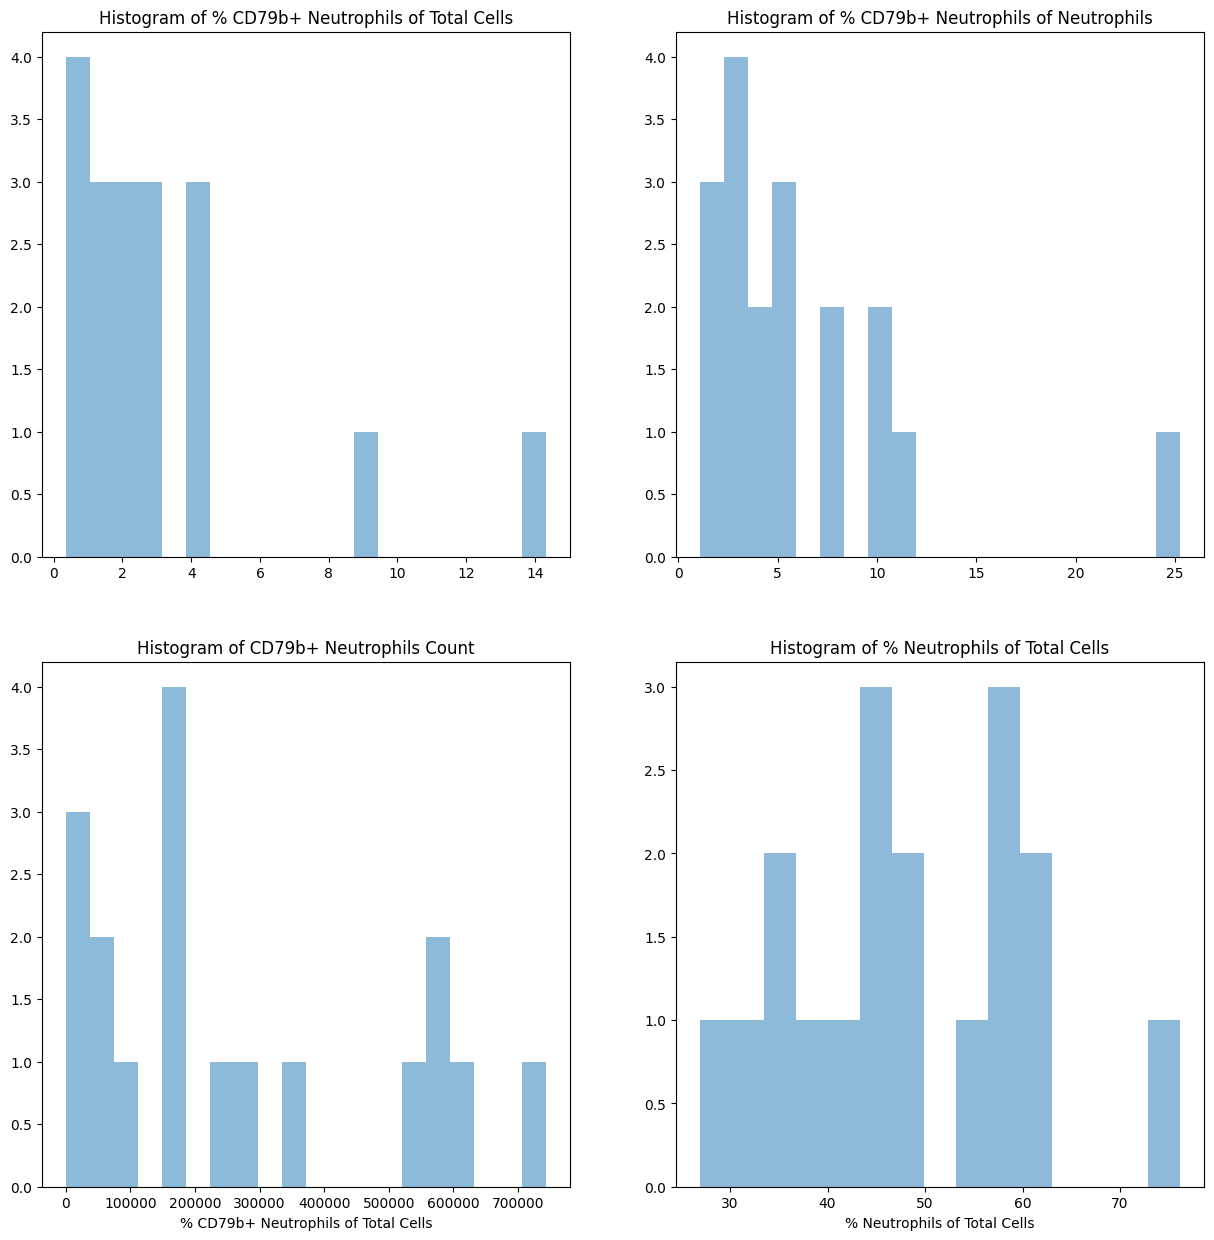

In [36]:
import matplotlib.pyplot as plt

# Create 4 histograms in a 2x2 grid
plt.figure(figsize = (15, 15))
plt.subplot(2, 2, 1)
plt.hist(healthy_data['% CD79b+ Neutrophils'], bins = 20, alpha = 0.5)
plt.title('Histogram of % CD79b+ Neutrophils of Total Cells')
plt.subplot(2, 2, 2)
plt.hist(healthy_data['% CD79b+ Neutrophils.1'], bins = 20, alpha = 0.5)
plt.title('Histogram of % CD79b+ Neutrophils of Neutrophils')
plt.subplot(2, 2, 3)
plt.hist(healthy_data['CD79b+ neutrophils'], bins = 20, alpha = 0.5)
plt.title("Histogram of CD79b+ Neutrophils Count")
plt.xlabel("% CD79b+ Neutrophils of Total Cells")
plt.subplot(2, 2, 4)
plt.hist(healthy_data['% Neutrophils'], bins = 15, alpha = 0.5)
plt.title("Histogram of % Neutrophils of Total Cells")
plt.xlabel("% Neutrophils of Total Cells")
plt.show()

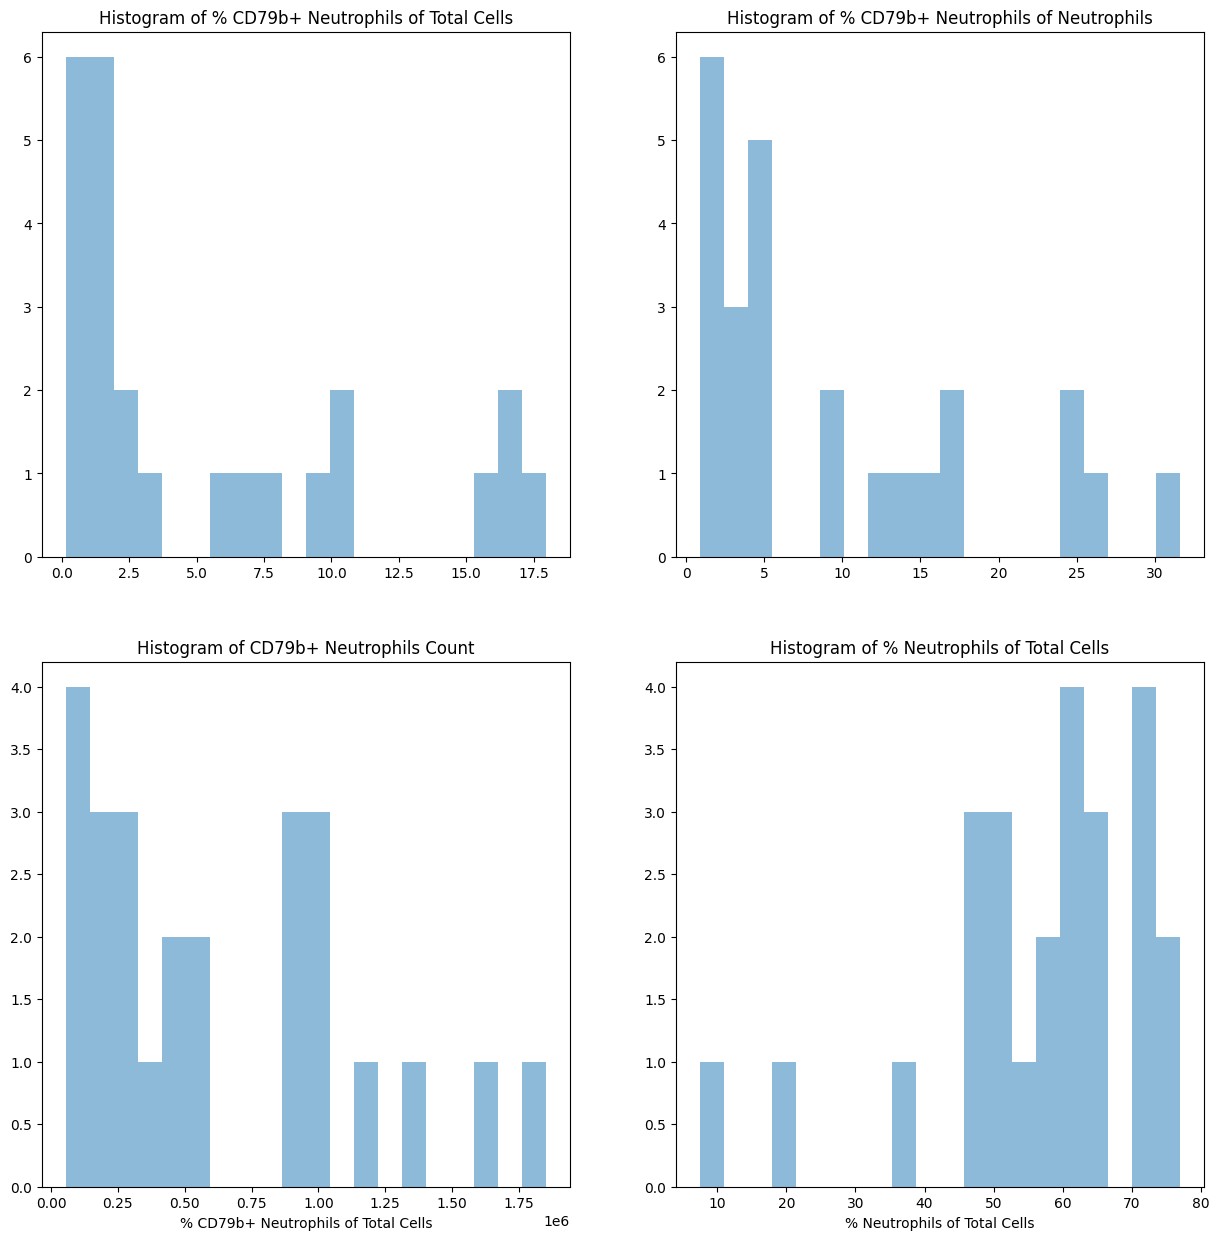

In [11]:
import matplotlib.pyplot as plt

# Create 4 histograms in a 2x2 grid
plt.figure(figsize = (15, 15))
plt.subplot(2, 2, 1)
plt.hist(hnscc_clean['% CD79b+ Neutrophils'], bins = 20, alpha = 0.5)
plt.title('Histogram of % CD79b+ Neutrophils of Total Cells')
plt.subplot(2, 2, 2)
plt.hist(hnscc_clean['% CD79b+ Neutrophils.1'], bins = 20, alpha = 0.5)
plt.title('Histogram of % CD79b+ Neutrophils of Neutrophils')
plt.subplot(2, 2, 3)
plt.hist(hnscc_clean['CD79b+ neutrophils'], bins = 20, alpha = 0.5)
plt.title("Histogram of CD79b+ Neutrophils Count")
plt.xlabel("% CD79b+ Neutrophils of Total Cells")
plt.subplot(2, 2, 4)
plt.hist(hnscc_clean['% Neutrophils'], bins = 20, alpha = 0.5)
plt.title("Histogram of % Neutrophils of Total Cells")
plt.xlabel("% Neutrophils of Total Cells")
plt.show()

Needs to be using kruskal-wallis test to compare these groups followed by dunn post hoc test,

For new data, wants to see the difference between responder vs nonresponder. Also anti-PD1 treatment (-mab). Also wants to see if possible to take gender out of the equation, see if this is an unbiased variable.
  









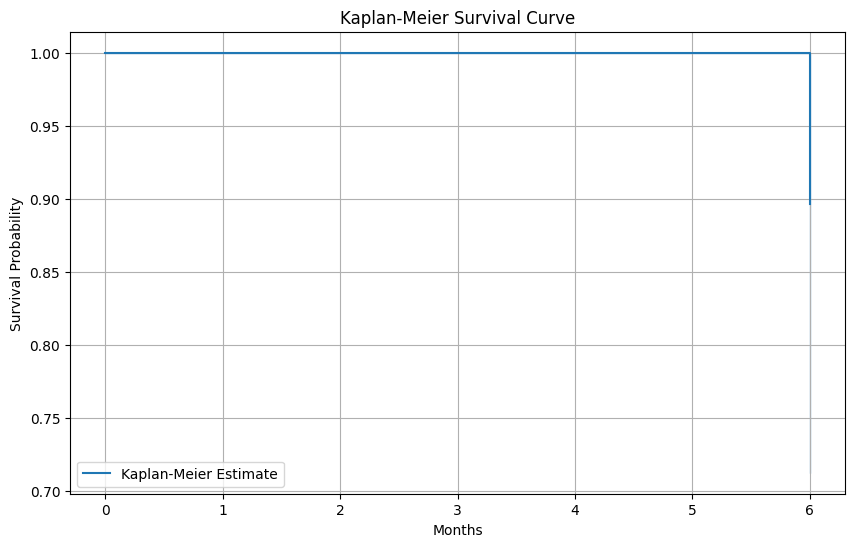

In [55]:
from lifelines import KaplanMeierFitter

data = pd.read_excel("follow up.xlsx", header=0)
data.drop('Assessment of Response', axis = 1, inplace = True)

kmf = KaplanMeierFitter()
kmf.fit(data['Months'], event_observed = data['Vital Status at 6 Month Follow-Up'], label='Kaplan-Meier Estimate')

plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve')
plt.xlabel('Months')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

In [ ]:
import scipy.stats as stats

# t test 
stats.ttest_ind(hnscc_clean['% CD79b+ Neutrophils'], healthy_clean['% CD79b+ Neutrophils'], equal_var = False)

TtestResult(statistic=np.float64(1.6426557328047358), pvalue=np.float64(0.10834732584920978), df=np.float64(39.72742874512458))

In [38]:
hnscc_stage = hnscc_clean[hnscc_clean['Calculated Stage '] > 0.0]
hnscc_stage

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils,Age,Sex,Race,Ethnicity,Diagnosis (as listed in KUMC excel),Final Diagnosis,Location,Metastisis,HPV status,staging,lymph node stage,Calculated Stage
0,64.692559,16.401306,25.352693,1.851707e+06,35.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,Tongue,NaN,NaN,pT4aN0,negative,4.0
1,71.077168,1.659306,2.334513,1.616993e+06,77.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, well-to moderately di...",Squamous cell carcinoma,"Tongue/oral cavity, Pharynx",negative,NaN,pT4a N0 M (N/A),negative,3.0
3,70.418280,10.309837,14.600000,1.154702e+06,83.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, keratinizing, moderat...",Squamous cell carcinoma,tongue,NaN,NaN,pT1pN0,negative,1.0
5,59.082132,15.575825,26.363004,9.843921e+05,73.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,"Oral mucosa, tongue",NaN,NaN,pT4aN3b,positive,4.0
8,51.127396,6.581172,12.872106,8.762831e+05,67.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, moderately differenti...",Squamous cell carcinoma of the oral cavity,Tongue,NaN,NaN,pT4aN0,negative,4.0
9,70.184651,2.200405,3.135166,5.619835e+05,49.0,Male,White,Not Hispanic or Latino,Moderately differentiated squamous cell carcin...,Squamous cell carcinoma,gingival mucosa,NaN,NaN,pT2pN0,negative,2.0
11,65.447223,10.547072,16.115385,4.993511e+05,57.0,Male,White,Not Hispanic or Latino,Human papillomavirus (HPV)-associated squamous...,HPV mediated squamous cell carcinoma,Tonsil,NaN,postive,pT2pN2,postitive,4.0
12,56.003139,9.424162,16.827918,4.735641e+05,60.0,Female,White,Not Hispanic or Latino,Squamous cell carcinoma,Squamous cell carcinoma of the oral cavity,"Neck, Oral cavity",NaN,NaN,pT2pN1,Positive,3.0
13,50.834092,1.347545,2.650869,3.258365e+05,43.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,Mandible bone,NaN,NaN,pT4aN3b,positive,4.0
14,61.225209,1.019539,1.665227,2.942898e+05,56.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,Tongue,NaN,NaN,pT3N0,negative*,3.0


In [39]:
hnscc_stage1 = hnscc_stage[hnscc_stage['Calculated Stage '] == 1.0]
hnscc_stage2 = hnscc_stage[hnscc_stage['Calculated Stage '] == 2.0]
hnscc_stage3 = hnscc_stage[hnscc_stage['Calculated Stage '] == 3.0]
hnscc_stage4 = hnscc_stage[hnscc_stage['Calculated Stage '] == 4.0]

In [40]:
hnscc_stage1

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils,Age,Sex,Race,Ethnicity,Diagnosis (as listed in KUMC excel),Final Diagnosis,Location,Metastisis,HPV status,staging,lymph node stage,Calculated Stage
3,70.418280,10.309837,14.600000,1.154702e+06,83.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, keratinizing, moderat...",Squamous cell carcinoma,tongue,NaN,NaN,pT1pN0,negative,1.0
20,76.987091,0.138696,1.801663,5.475728e+04,42.0,Male,White,Not Hispanic or Latino,Human papillomavirus (HPV)-mediated squamous c...,HPV mediated squamous cell carcinoma,"Tonsil, oropharynx, lymph node",positive,Positive,PT1 pN1 ENE (+),Positive,1.0
21,46.500000,1.840000,3.970000,9.328800e+05,51.0,Male,White,Not Hispanic or Latino,"Oropharyngeal squamous cell carcinoma, HPV ass...",Oropharyngeal Squamous cell carcinoma,Tonsil,NaN,postive,pT1,negative,1.0


In [41]:
hnscc_stage2

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils,Age,Sex,Race,Ethnicity,Diagnosis (as listed in KUMC excel),Final Diagnosis,Location,Metastisis,HPV status,staging,lymph node stage,Calculated Stage
9,70.184651,2.200405,3.135166,561983.504095,49.0,Male,White,Not Hispanic or Latino,Moderately differentiated squamous cell carcin...,Squamous cell carcinoma,gingival mucosa,NaN,NaN,pT2pN0,negative,2.0
18,60.606628,2.752294,4.541242,151513.761468,78.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, moderately differenti...",Squamous cell carcinoma of the oral cavity,Gum,NaN,NaN,pT2pN0,negative,2.0


In [42]:
hnscc_stage3

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils,Age,Sex,Race,Ethnicity,Diagnosis (as listed in KUMC excel),Final Diagnosis,Location,Metastisis,HPV status,staging,lymph node stage,Calculated Stage
1,71.077168,1.659306,2.334513,1.616993e+06,77.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, well-to moderately di...",Squamous cell carcinoma,"Tongue/oral cavity, Pharynx",negative,NaN,pT4a N0 M (N/A),negative,3.0
12,56.003139,9.424162,16.827918,4.735641e+05,60.0,Female,White,Not Hispanic or Latino,Squamous cell carcinoma,Squamous cell carcinoma of the oral cavity,"Neck, Oral cavity",NaN,NaN,pT2pN1,Positive,3.0
14,61.225209,1.019539,1.665227,2.942898e+05,56.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,Tongue,NaN,NaN,pT3N0,negative*,3.0
16,46.261079,7.546683,16.313244,2.020247e+05,61.0,Female,White,Not Hispanic or Latino,HPV mediated squamous cell carcinoma of the or...,HPV mediated squamous cell carcinoma,"oropharynx, tonsil",NaN,Positive,pT2pN1,positive,3.0
23,7.490000,0.690000,9.180000,1.250625e+05,58.0,Male,White,Not Hispanic or Latino,Human papillomavirus / HPV-mediated squamous ...,HPV mediated squamous cell carcinoma,oropharynx,positive,positive,pT2pN1,Positive,3.0


In [43]:
hnscc_stage4

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils,Age,Sex,Race,Ethnicity,Diagnosis (as listed in KUMC excel),Final Diagnosis,Location,Metastisis,HPV status,staging,lymph node stage,Calculated Stage
0,64.692559,16.401306,25.352693,1.851707e+06,35.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,Tongue,NaN,NaN,pT4aN0,negative,4.0
5,59.082132,15.575825,26.363004,9.843921e+05,73.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,"Oral mucosa, tongue",NaN,NaN,pT4aN3b,positive,4.0
8,51.127396,6.581172,12.872106,8.762831e+05,67.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, moderately differenti...",Squamous cell carcinoma of the oral cavity,Tongue,NaN,NaN,pT4aN0,negative,4.0
11,65.447223,10.547072,16.115385,4.993511e+05,57.0,Male,White,Not Hispanic or Latino,Human papillomavirus (HPV)-associated squamous...,HPV mediated squamous cell carcinoma,Tonsil,NaN,postive,pT2pN2,postitive,4.0
13,50.834092,1.347545,2.650869,3.258365e+05,43.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,Mandible bone,NaN,NaN,pT4aN3b,positive,4.0
17,60.905829,5.976590,9.810000,1.596347e+05,32.0,Female,White,Hispanic or Latino,"Squamous cell carcinoma, moderate to poorly di...",Squamous cell carcinoma,tongue,NaN,NaN,pT4apN0,negative,4.0
19,60.511612,3.085167,5.098471,1.252578e+05,74.0,Male,White,Not Hispanic or Latino,"Invasive, moderately differentiated keratinizi...",Squamous cell carcinoma of the oral cavity,Oral cavity,NaN,NaN,pT4apN0,negative,4.0
24,20.900000,0.910000,4.370000,9.227400e+04,51.0,Male,White,Not Hispanic or Latino,Invasive moderately to poorly differentiated s...,Squamous cell carcinoma,tongue,positive,NaN,pT4apN3b,Positive,4.0


In [ ]:
You can analyze the stages of HNSCC (Head and Neck Squamous Cell Carcinoma) to gain insights into the data. Here are some ideas:

1. **Distribution Analysis**:
    - Plot the distribution of patients across different stages using a bar chart or pie chart.

2. **Statistical Comparison**:
    - Compare the values of key metrics (e.g., `% CD79b+ Neutrophils`, `Age`) across different stages using statistical tests like ANOVA or t-tests.

3. **Correlation Analysis**:
    - Analyze the correlation between `Calculated Stage` and other numerical features.

4. **Visualization**:
    - Create boxplots or violin plots to visualize the distribution of numerical features across stages.

5. **Survival Analysis**:
    - If survival data is available, perform survival analysis to study the impact of stages on patient outcomes.

6. **Feature Importance**:
    - Use machine learning models to identify features that are most predictive of the stage.

7. **Group-wise Analysis**:
    - Analyze demographic or clinical differences (e.g., `Sex`, `Race`, `HPV status`) across stages.

Let me know which analysis you'd like to perform, and I can help you write the code!
```python
from scipy.stats import f_oneway

# Perform ANOVA to compare % CD79b+ Neutrophils across stages
anova_result = f_oneway(hnscc_stage1['% CD79b+ Neutrophils'], 
                        hnscc_stage2['% CD79b+ Neutrophils'], 
                        hnscc_stage3['% CD79b+ Neutrophils'], 
                        hnscc_stage4['% CD79b+ Neutrophils'])

anova_result
```python
# Perform t-tests to compare % CD79b+ Neutrophils between each stage and healthy patients
t_test_stage1 = stats.ttest_ind(hnscc_stage1['% CD79b+ Neutrophils'], healthy_clean['% CD79b+ Neutrophils'], equal_var=False)
t_test_stage2 = stats.ttest_ind(hnscc_stage2['% CD79b+ Neutrophils'], healthy_clean['% CD79b+ Neutrophils'], equal_var=False)
t_test_stage3 = stats.ttest_ind(hnscc_stage3['% CD79b+ Neutrophils'], healthy_clean['% CD79b+ Neutrophils'], equal_var=False)
t_test_stage4 = stats.ttest_ind(hnscc_stage4['% CD79b+ Neutrophils'], healthy_clean['% CD79b+ Neutrophils'], equal_var=False)

t_test_stage1, t_test_stage2, t_test_stage3, t_test_stage4
```python
# Evaluate statistical significance of t-tests
P
```

In [ ]:
from scipy.stats import f_oneway

anova_result = f_oneway(hnscc_stage1['% CD79b+ Neutrophils'], 
                        hnscc_stage2['% CD79b+ Neutrophils'], 
                        hnscc_stage3['% CD79b+ Neutrophils'],
                        hnscc_stage4['% CD79b+ Neutrophils'])

anova_result

F_onewayResult(statistic=np.float64(0.826824656585741), pvalue=np.float64(0.5007894985430368))

In [ ]:
t_test_stage1 = stats.ttest_ind(hnscc_stage1['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'], equal_var=False)
t_test_stage2 = stats.ttest_ind(hnscc_stage2['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'], equal_var=False)
t_test_stage3 = stats.ttest_ind(hnscc_stage3['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'], equal_var=False)
t_test_stage4 = stats.ttest_ind(hnscc_stage4['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'], equal_var=False)

t_test_stage1, t_test_stage2, t_test_stage3, t_test_stage4

(TtestResult(statistic=np.float64(1.3136992552620153), pvalue=np.float64(0.31365320813287567), df=np.float64(2.108589018895414)),
 TtestResult(statistic=np.float64(0.422190831293264), pvalue=np.float64(0.7382709374143084), df=np.float64(1.1485084759775832)),
 TtestResult(statistic=np.float64(0.9822490899610051), pvalue=np.float64(0.3776771575405677), df=np.float64(4.325226341846808)),
 TtestResult(statistic=np.float64(1.575539650649454), pvalue=np.float64(0.15403513524110107), df=np.float64(7.946306897633376)))

In [ ]:
from scipy.stats import mannwhitneyu

mannwhitneyu_stage1 = mannwhitneyu(hnscc_stage1['% CD79b+ Neutrophils'], healthy_clean['% CD79b+ Neutrophils'])
mannwhitneyu_stage2 = mannwhitneyu(hnscc_stage2['% CD79b+ Neutrophils'], healthy_clean['% CD79b+ Neutrophils'])
mannwhitneyu_stage3 = mannwhitneyu(hnscc_stage3['% CD79b+ Neutrophils'], healthy_clean['% CD79b+ Neutrophils'])
mannwhitneyu_stage4 = mannwhitneyu(hnscc_stage4['% CD79b+ Neutrophils'], healthy_clean['% CD79b+ Neutrophils'])

results = {
    "Stage 1": mannwhitneyu_stage1.pvalue,
    "Stage 2": mannwhitneyu_stage2.pvalue,
    "Stage 3": mannwhitneyu_stage3.pvalue,
    "Stage 4": mannwhitneyu_stage4.pvalue
}

# Determine statistical significance at alpha = 0.05
significance = {stage: "Significant" if pval < 0.05 else "Not Significant" for stage, pval in results.items()}
significance

{'Stage 1': 'Not Significant',
 'Stage 2': 'Not Significant',
 'Stage 3': 'Not Significant',
 'Stage 4': 'Not Significant'}

In [ ]:
mannwhitneyu_stage1 = mannwhitneyu(hnscc_stage1['% CD79b+ Neutrophils.1'], healthy_clean['% CD79b+ Neutrophils.1'])
mannwhitneyu_stage2 = mannwhitneyu(hnscc_stage2['% CD79b+ Neutrophils.1'], healthy_clean['% CD79b+ Neutrophils.1'])
mannwhitneyu_stage3 = mannwhitneyu(hnscc_stage3['% CD79b+ Neutrophils.1'], healthy_clean['% CD79b+ Neutrophils.1'])
mannwhitneyu_stage4 = mannwhitneyu(hnscc_stage4['% CD79b+ Neutrophils.1'], healthy_clean['% CD79b+ Neutrophils.1'])

results = {
    "Stage 1": mannwhitneyu_stage1.pvalue,
    "Stage 2": mannwhitneyu_stage2.pvalue,
    "Stage 3": mannwhitneyu_stage3.pvalue,
    "Stage 4": mannwhitneyu_stage4.pvalue
}

# Determine statistical significance at alpha = 0.05
significance = {stage: "Significant" if pval < 0.05 else "Not Significant" for stage, pval in results.items()}
significance

{'Stage 1': 'Not Significant',
 'Stage 2': 'Not Significant',
 'Stage 3': 'Not Significant',
 'Stage 4': 'Not Significant'}

In [ ]:
mannwhitneyu_stage1 = mannwhitneyu(hnscc_stage1['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'])
mannwhitneyu_stage2 = mannwhitneyu(hnscc_stage2['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'])
mannwhitneyu_stage3 = mannwhitneyu(hnscc_stage3['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'])
mannwhitneyu_stage4 = mannwhitneyu(hnscc_stage4['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'])

results = {
    "Stage 1": mannwhitneyu_stage1.pvalue,
    "Stage 2": mannwhitneyu_stage2.pvalue,
    "Stage 3": mannwhitneyu_stage3.pvalue,
    "Stage 4": mannwhitneyu_stage4.pvalue
}

# Determine statistical significance at alpha = 0.05
significance = {stage: "Significant" if pval < 0.05 else "Not Significant" for stage, pval in results.items()}
significance

{'Stage 1': 'Not Significant',
 'Stage 2': 'Not Significant',
 'Stage 3': 'Not Significant',
 'Stage 4': 'Not Significant'}

In [ ]:
hnscc_ln_pos = hnscc_clean[hnscc_clean['lymph node stage'].isin(['Positive', 'positive', 'postitive'])]
hnscc_ln_pos

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils,Age,Sex,Race,Ethnicity,Diagnosis (as listed in KUMC excel),Final Diagnosis,Location,Metastisis,HPV status,staging,lymph node stage,Calculated Stage
5,59.082132,15.575825,26.363004,984392.127861,73.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,"Oral mucosa, tongue",NaN,NaN,pT4aN3b,positive,4.0
11,65.447223,10.547072,16.115385,499351.107568,57.0,Male,White,Not Hispanic or Latino,Human papillomavirus (HPV)-associated squamous...,HPV mediated squamous cell carcinoma,Tonsil,NaN,postive,pT2pN2,postitive,4.0
12,56.003139,9.424162,16.827918,473564.141848,60.0,Female,White,Not Hispanic or Latino,Squamous cell carcinoma,Squamous cell carcinoma of the oral cavity,"Neck, Oral cavity",NaN,NaN,pT2pN1,Positive,3.0
13,50.834092,1.347545,2.650869,325836.474717,43.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,Mandible bone,NaN,NaN,pT4aN3b,positive,4.0
16,46.261079,7.546683,16.313244,202024.696670,61.0,Female,White,Not Hispanic or Latino,HPV mediated squamous cell carcinoma of the or...,HPV mediated squamous cell carcinoma,"oropharynx, tonsil",NaN,Positive,pT2pN1,positive,3.0
20,76.987091,0.138696,1.801663,54757.281553,42.0,Male,White,Not Hispanic or Latino,Human papillomavirus (HPV)-mediated squamous c...,HPV mediated squamous cell carcinoma,"Tonsil, oropharynx, lymph node",positive,Positive,PT1 pN1 ENE (+),Positive,1.0
23,7.490000,0.690000,9.180000,125062.500000,58.0,Male,White,Not Hispanic or Latino,Human papillomavirus / HPV-mediated squamous ...,HPV mediated squamous cell carcinoma,oropharynx,positive,positive,pT2pN1,Positive,3.0
24,20.900000,0.910000,4.370000,92274.000000,51.0,Male,White,Not Hispanic or Latino,Invasive moderately to poorly differentiated s...,Squamous cell carcinoma,tongue,positive,NaN,pT4apN3b,Positive,4.0


In [ ]:
hnscc_ln_neg = hnscc_clean[hnscc_clean['lymph node stage'].isin(['Negative', 'negative', 'negative*'])]
hnscc_ln_neg

,% Neutrophils,% CD79b+ Neutrophils,% CD79b+ Neutrophils.1,CD79b+ neutrophils,Age,Sex,Race,Ethnicity,Diagnosis (as listed in KUMC excel),Final Diagnosis,Location,Metastisis,HPV status,staging,lymph node stage,Calculated Stage
0,64.692559,16.401306,25.352693,1.851707e+06,35.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,Tongue,NaN,NaN,pT4aN0,negative,4.0
1,71.077168,1.659306,2.334513,1.616993e+06,77.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, well-to moderately di...",Squamous cell carcinoma,"Tongue/oral cavity, Pharynx",negative,NaN,pT4a N0 M (N/A),negative,3.0
3,70.418280,10.309837,14.600000,1.154702e+06,83.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, keratinizing, moderat...",Squamous cell carcinoma,tongue,NaN,NaN,pT1pN0,negative,1.0
8,51.127396,6.581172,12.872106,8.762831e+05,67.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, moderately differenti...",Squamous cell carcinoma of the oral cavity,Tongue,NaN,NaN,pT4aN0,negative,4.0
9,70.184651,2.200405,3.135166,5.619835e+05,49.0,Male,White,Not Hispanic or Latino,Moderately differentiated squamous cell carcin...,Squamous cell carcinoma,gingival mucosa,NaN,NaN,pT2pN0,negative,2.0
14,61.225209,1.019539,1.665227,2.942898e+05,56.0,Female,White,Not Hispanic or Latino,"Squamous cell carcinoma, conventional (keratin...",Squamous cell carcinoma,Tongue,NaN,NaN,pT3N0,negative*,3.0
17,60.905829,5.976590,9.810000,1.596347e+05,32.0,Female,White,Hispanic or Latino,"Squamous cell carcinoma, moderate to poorly di...",Squamous cell carcinoma,tongue,NaN,NaN,pT4apN0,negative,4.0
18,60.606628,2.752294,4.541242,1.515138e+05,78.0,Male,White,Not Hispanic or Latino,"Squamous cell carcinoma, moderately differenti...",Squamous cell carcinoma of the oral cavity,Gum,NaN,NaN,pT2pN0,negative,2.0
19,60.511612,3.085167,5.098471,1.252578e+05,74.0,Male,White,Not Hispanic or Latino,"Invasive, moderately differentiated keratinizi...",Squamous cell carcinoma of the oral cavity,Oral cavity,NaN,NaN,pT4apN0,negative,4.0
21,46.500000,1.840000,3.970000,9.328800e+05,51.0,Male,White,Not Hispanic or Latino,"Oropharyngeal squamous cell carcinoma, HPV ass...",Oropharyngeal Squamous cell carcinoma,Tonsil,NaN,postive,pT1,negative,1.0


In [ ]:
# Compare LN Neg and Pos to healthy

mannwhitneyu_neg = mannwhitneyu(hnscc_ln_neg['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'])
mannwhitneyu_pos = mannwhitneyu(hnscc_ln_pos['CD79b+ neutrophils'], healthy_clean['CD79b+ neutrophils'])

results = {
    "LN Negative": mannwhitneyu_neg.pvalue,
    "LN Positive": mannwhitneyu_pos.pvalue
}

# Determine statistical significance at alpha = 0.05
significance = {stage: "Significant" if pval < 0.05 else "Not Significant" for stage, pval in results.items()}
significance

{'LN Negative': 'Significant', 'LN Positive': 'Not Significant'}

<ErrorbarContainer object of 3 artists>

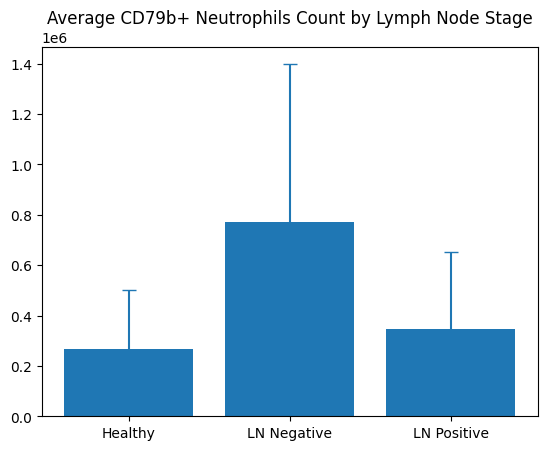

In [ ]:
plt.bar(['Healthy','LN Negative', 'LN Positive'], [healthy_clean['CD79b+ neutrophils'].mean(), hnscc_ln_neg['CD79b+ neutrophils'].mean(), hnscc_ln_pos['CD79b+ neutrophils'].mean()])
plt.title('Average CD79b+ Neutrophils Count by Lymph Node Stage')
plt.errorbar(['Healthy','LN Negative', 'LN Positive'], [healthy_clean['CD79b+ neutrophils'].mean(), hnscc_ln_neg['CD79b+ neutrophils'].mean(), hnscc_ln_pos['CD79b+ neutrophils'].mean()], 
             yerr=[healthy_clean['CD79b+ neutrophils'].std(), hnscc_ln_neg['CD79b+ neutrophils'].std(), hnscc_ln_pos['CD79b+ neutrophils'].std()], fmt='none', capsize=5)

<BarContainer object of 2 artists>

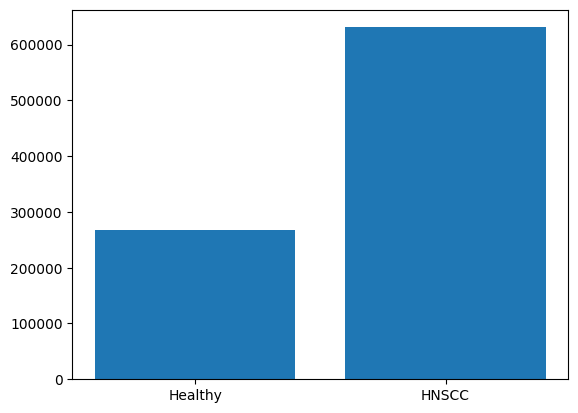

In [ ]:
plt.bar(['Healthy', 'HNSCC'], [healthy_clean['CD79b+ neutrophils'].mean(), hnscc_clean['CD79b+ neutrophils'].mean()])

In [ ]:
hnscc_clean.columns

Index(['% Neutrophils', '% CD79b+ Neutrophils', '% CD79b+ Neutrophils.1',
       'CD79b+ neutrophils', 'Age', 'Sex', 'Race', 'Ethnicity',
       'Diagnosis (as listed in KUMC excel)', 'Final Diagnosis ', 'Location',
       'Metastisis', 'HPV status', 'staging', 'lymph node stage',
       'Calculated Stage '],
      dtype='object')

<Axes: xlabel='Calculated Stage ', ylabel='CD79b+ neutrophils'>

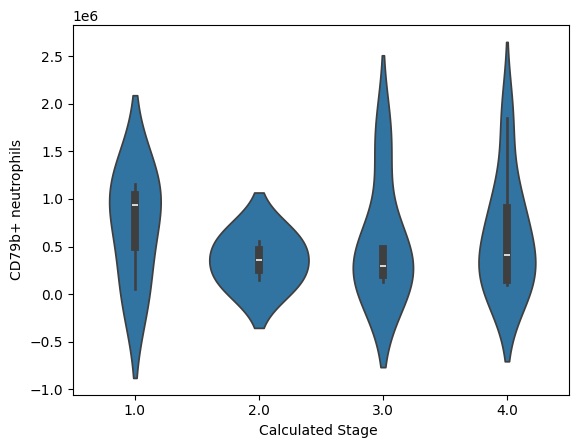

In [ ]:
sns.violinplot(x = 'Calculated Stage ', y = 'CD79b+ neutrophils', data = hnscc_clean)